# A dynamic task assignment model (TTAP) - Exact Method

## Objective Function with Time-Dependent Sigmoidal Benefit

The Target--Task Allocation Problem (TTAP) seeks to maximize the total operational benefit obtained by assigning heterogeneous agents to disaster-response tasks under temporal and capability constraints.

Let \(H\) be the set of agents, \(I\) the set of tasks, and \(x_{hi}\) a binary decision variable equal to 1 if agent \(h\) is assigned to task \(i\), and 0 otherwise.

The time-dependent objective function is defined as:

$
\max Z = \sum_{h \in H} \sum_{i \in I} V_i \, p_{hi} \, S_i(t_{hi}^{\mathrm{end}})\, x_{hi}
$

where:

- $(V_i)$ is the operational priority or value of task \(i\),
- $(p_{hi})$ is the effectiveness or suitability of agent \(h\) for task \(i\),
- $(S_i(t_{hi}^{\mathrm{end}}))$ is a sigmoidal satisfaction function that captures the time sensitivity of task \(i\),
- $(t_{hi}^{\mathrm{end}})$ is the completion time of task \(i\) if executed by agent \(h\).

The completion time is computed as:

$
t_{hi}^{\mathrm{end}} = t_h^{\mathrm{avail}} + t_{hi}^{\mathrm{flight}} + s_i
$

where:

- $(t_h^{\mathrm{avail}})$ is the earliest time at which agent \(h\) becomes available,
- $(t_{hi}^{\mathrm{flight}})$ is the travel time from the current location of agent \(h\) to task \(i\),
- $(s_i)$ is the service time required to complete task \(i\).

The flight time is given by:

$
t_{hi}^{\mathrm{flight}} = \frac{60\, d_{hi}}{v_h}
$

where:

- $(d_{hi})$ is the distance between agent \(h\) and task \(i\),
- $(v_h)$ is the cruise speed of agent \(h\).

To model the time-dependent decay in the benefit of serving a task, the following logistic function is used:

$
S_i(t) = \frac{1}{1 + \exp\left(\alpha_i (t - \tau_i)\right)}
$

where:

- $(\alpha_i > 0)$ controls the steepness of the decay,
- $(\tau_i)$ is the critical time threshold or inflection point for task \(i\).

This function satisfies the following behavior:

- if $(t \ll \tau_i)$, then $(S_i(t) \approx 1)$, meaning the task is served on time and yields nearly full benefit;
- if $(t \approx \tau_i)$, the benefit starts to decay significantly;
- if $(t \gg \tau_i)$, then $(S_i(t) \approx 0)$, meaning the task is completed too late and yields little operational value.

Therefore, the objective function simultaneously captures:

1. the intrinsic importance of each task through $(V_i)$,
2. the compatibility or effectiveness of each agent-task pair through $(p_{hi})$,
3. the urgency of task completion through the sigmoidal term $(S_i(t_{hi}^{\mathrm{end}}))$.

This formulation extends the classical WTA structure by incorporating temporal sensitivity, which is essential in Humanitarian Assistance and Disaster Relief (HA/DR) environments, where delayed service may drastically reduce mission effectiveness.

### Restricciones

#### 1. Asignación Única de Tareas
Cada tarea puede ejecutarse a lo más una vez:

$
\sum_{h \in H} x_{hi} \leq 1, \quad \forall i \in I
$

#### 2. Exclusividad de los Agentes
Un agente no puede ejecutar más de una tarea simultáneamente:

$
\sum_{i \in I} x_{hi} \leq 1, \quad \forall h \in H
$

$
\sum_{i \in I} x_{hit} \leq 1, \quad \forall h \in H,\, t \in T
$

#### 3. Conservación de Flujo en la Red Espacio-Temporal
Garantiza la continuidad de la trayectoria de cada agente:

$
\sum_{a \in \delta^+(n,t)} x_{h,a} -
\sum_{a \in \delta^-(n,t)} x_{h,a} =
\begin{cases}
1, & \text{si } (n,t) \text{ es el nodo inicial}, \\
-1, & \text{si } (n,t) \text{ es el nodo final}, \\
0, & \text{en otro caso}.
\end{cases}
$

#### 4. Restricciones de Capacidad
Un agente solo puede ejecutar tareas compatibles con sus capacidades:

$
req_{ik} \, x_{hi} \leq cap_{hk}, \quad
\forall h \in H,\, i \in I,\, k \in K
$

#### 5. Restricción del Horizonte Temporal
Las tareas deben finalizar dentro del tiempo máximo de la misión:

$
t_{hi}^{\text{end}} \leq T_{\max}, \quad
\forall h \in H,\, i \in I
$

#### 6. Restricción de Factibilidad Temporal
$
t_{hi}^{\text{end}} =
t_h^{\text{avail}} + t_{hi}^{\text{flight}} + s_i
$

#### 7. Cálculo del Tiempo de Vuelo
$
t_{hi}^{\text{flight}} = \frac{60\, d_{hi}}{v_h}
$

#### 8. Naturaleza Binaria de las Variables
$
x_{hi} \in \{0,1\}
$

In [9]:
import math
import numpy as np
import pandas as pd
from collections import defaultdict
from scipy.optimize import milp, LinearConstraint, Bounds
from scipy.sparse import coo_matrix

# ==========================================
# 1. DATOS DEL ESCENARIO
# ==========================================
nodes = {"Base": (0,0), "A": (10,5), "B": (20,15), "C": (30,10), "D": (40,20)}

helicopters = {
    "H1": {"hovering": True,  "load": 500, "med": 3, "pers": 3, "speed": 150},
    "H2": {"hovering": False, "load": 500, "med": 3, "pers": 3, "speed": 120},
    "H3": {"hovering": True,  "load": 500, "med": 3, "pers": 3, "speed": 140},
    "H4": {"hovering": False, "load": 500, "med": 3, "pers": 3, "speed": 160},
}

task_rows = [
    (1, True, 200, 2, 1, 20, 40, 60),  
    (2, False,300, 1, 2, 15, 30, 50),
    (3, True, 100, 3, 0, 10, 25, 40),  
    (4, False,200, 0, 3, 30, 50, 70),
    (5, True, 150, 1, 1, 25, 45, 60),  
    (6, True, 100, 3, 0, 10, 25, 120),
    (7, False,400, 0, 3, 30, 50, 90),  
    (8, True, 150, 1, 1, 25, 45, 100),
    (9, True, 200, 2, 1, 20, 40, 60),  
    (10,False,300, 1, 2, 15, 30, 50),
    (11,True, 100, 3, 0, 10, 25, 40),  
    (12,False,200, 0, 3, 30, 50, 70),
    (13,True, 150, 1, 1, 25, 45, 60),  
    (14,True, 100, 3, 0, 10, 25, 120),
    (15,False,400, 0, 3, 30, 50, 90),  
    (16,True, 150, 1, 1, 25, 45, 100),
    (17,True, 150, 1, 1, 25, 45, 60),  
    (18,True, 100, 3, 0, 10, 25, 120),
    (19,False,400, 0, 3, 30, 50, 90),  
    (20,True, 150, 1, 1, 25, 45, 100),
]
tasks = {r[0]: dict(hover_req=r[1], transport=r[2], med=r[3], pers=r[4], t_opt=r[5], t_eff=r[6], t_ineff=r[7]) for r in task_rows}

task_to_node = {}
for i in [1,2,9,10]: task_to_node[i] = "A"
for i in [3,8,7,11,12,13,14]: task_to_node[i] = "B"
for i in [5,6,15,16]: task_to_node[i] = "C"
for i in [4,17,18,19,20]: task_to_node[i] = "D"

# ==========================================
# 2. PARÁMETROS ESPACIO-TEMPORALES
# ==========================================
time_unit = 1.0    # 1 minuto por paso (para contener el tamaño de la matriz)
Tmax_min = 250
Tmax = int(Tmax_min / time_unit)
alpha = 0.1
v_norm = 1.0 / len(tasks)

def euclid(a,b): return math.hypot(a[0]-b[0], a[1]-b[1])

def travel_time_steps(n1,n2,speed=150):
    if n1 == n2: return 0
    d = euclid(nodes[n1], nodes[n2])
    return int(round((60.0 * d / speed) / time_unit))

def service_time_steps(task_id):
    # Restaurado a los 6 minutos fijos que utiliza el algoritmo Greedy
    return int(math.ceil(6.0 / time_unit))

def satisfaction(t_min, t_opt, t_eff, t_ineff):
    if t_min <= t_opt: return 1.0
    if t_min >= t_ineff: return 0.0
    return 1.0 / (1.0 + math.exp(alpha*(t_min - t_eff)))

# ==========================================
# 3. CONSTRUCCIÓN DE LA RED (DAG)
# ==========================================
arcs = []
# 3.1 Arcos de Espera (Wait)
for n in nodes:
    for t in range(Tmax):
        arcs.append({"id": len(arcs), "from": (n,t), "to": (n,t+1), "kind": "wait", "demand": {"load":0, "med":0, "pers":0}})

# 3.2 Arcos de Viaje (Travel)
for n1 in nodes:
    for n2 in nodes:
        if n1 == n2: continue
        dt = travel_time_steps(n1,n2)
        for t in range(Tmax + 1 - dt):
            arcs.append({"id": len(arcs), "from": (n1,t), "to": (n2,t+dt), "kind": "travel", "demand": {"load":0, "med":0, "pers":0}})

# 3.3 Arcos de Tarea (Task)
for i, task in tasks.items():
    n = task_to_node[i]
    dt = service_time_steps(i)
    dem = {"load": task["transport"], "med": task["med"], "pers": task["pers"]}

    max_time_allowed = task["t_ineff"] + 30.0
    max_step = int(max_time_allowed / time_unit)

    limit_t = min(Tmax + 1 - dt, max_step)
    
    for t in range(limit_t):
        arcs.append({"id": len(arcs), "from": (n,t), "to": (n,t+dt), "kind": "task", "task": i, "demand": dem})

# ==========================================
# 4. DEFINICIÓN DE VARIABLES
# ==========================================
H = list(helicopters.keys())
resources = ["load", "med", "pers"]

var_x = {} # Variables de flujo (Binarias)
var_q = {} # Variables de estado de recursos (Continuas)
idx = 0

for h in H:
    for a in arcs:
        var_x[(h, a["id"])] = idx
        idx += 1

x_count = idx

for h in H:
    for n in nodes:
        for t in range(Tmax + 1):
            for r in resources:
                var_q[(h, n, t, r)] = idx
                idx += 1

n_vars = idx

# Configuración de cotas y tipo
c = np.zeros(n_vars)
lb = np.zeros(n_vars)
ub = np.zeros(n_vars)
integrality = np.zeros(n_vars, dtype=int) # 0 = Continuous, 1 = Integer/Binary

# Cotas para X y Función Objetivo
for h in H:
    for a in arcs:
        v_id = var_x[(h, a["id"])]
        integrality[v_id] = 1 
        ub[v_id] = 1.0
        
        if a["kind"] == "task":
            i = a["task"]
            # Filtrado por compatibilidad estática
            if tasks[i]["hover_req"] and not helicopters[h]["hovering"]:
                ub[v_id] = 0.0
                continue
            if (tasks[i]["transport"] > helicopters[h]["load"] or 
                tasks[i]["med"] > helicopters[h]["med"] or 
                tasks[i]["pers"] > helicopters[h]["pers"]):
                ub[v_id] = 0.0
                continue
            
            # Recompensa Logística (Sigmoide)
            t_end = a["to"][1] * time_unit
            f = satisfaction(t_end, tasks[i]["t_opt"], tasks[i]["t_eff"], tasks[i]["t_ineff"])
            
            # TIE-BREAKER: Bono microscópico por terminar temprano
            time_bonus = 0.00001 * (Tmax_min - t_end)
            penalty_avoidance = 1000.0
            
            c[v_id] = -(v_norm * f + time_bonus + penalty_avoidance)

# Cotas para Q (Estado de Recursos)
for h in H:
    caps = {"load": helicopters[h]["load"], "med": helicopters[h]["med"], "pers": helicopters[h]["pers"]}
    for n in nodes:
        for t in range(Tmax + 1):
            for r in resources:
                v_id = var_q[(h, n, t, r)]
                if n == "Base":
                    # REABASTECIMIENTO OBLIGATORIO: Si está en Base, la capacidad es máxima
                    lb[v_id] = caps[r]
                    ub[v_id] = caps[r]
                else:
                    lb[v_id] = 0.0
                    ub[v_id] = caps[r]

# ==========================================
# 5. RESTRICCIONES ESTRUCTURALES
# ==========================================
row_idx = []; col_idx = []; vals = []; rhs_lb = []; rhs_ub = []
current_row = 0

# 5.1 Conservación de Flujo
for h in H:
    for n in nodes:
        for t in range(Tmax): # Excluye nodo sumidero Tmax
            b = 1.0 if (n == "Base" and t == 0) else 0.0
            
            out_arcs = [a for a in arcs if a["from"] == (n,t)]
            in_arcs = [a for a in arcs if a["to"] == (n,t)]
            
            for a in out_arcs:
                row_idx.append(current_row); col_idx.append(var_x[(h, a["id"])]); vals.append(1.0)
            for a in in_arcs:
                row_idx.append(current_row); col_idx.append(var_x[(h, a["id"])]); vals.append(-1.0)
            
            rhs_lb.append(b); rhs_ub.append(b)
            current_row += 1

# 5.2 Set Packing (Cada tarea máximo 1 vez por la flota)
for i in tasks:
    task_arcs = [a for a in arcs if a.get("task") == i]
    for h in H:
        for a in task_arcs:
            row_idx.append(current_row); col_idx.append(var_x[(h, a["id"])]); vals.append(1.0)
    rhs_lb.append(-np.inf); rhs_ub.append(1.0)
    current_row += 1

# 5.3 Transición de Recursos (RCSP via Big-M)
for h in H:
    caps = {"load": helicopters[h]["load"], "med": helicopters[h]["med"], "pers": helicopters[h]["pers"]}
    for a in arcs:
        u_node, u_time = a["from"]
        w_node, w_time = a["to"]
        
        # Ignoramos arcos que van directo a la Base, porque allí el recurso se resetea por cota
        if w_node == "Base": 
            continue 

        for r in resources:
            M = caps[r]
            d = a["demand"][r]
            
            idx_x = var_x[(h, a["id"])]
            idx_q_u = var_q[(h, u_node, u_time, r)]
            idx_q_w = var_q[(h, w_node, w_time, r)]
            
            # Ecuación: q_w - q_u + M*x_a <= M - d
            row_idx.extend([current_row, current_row, current_row])
            col_idx.extend([idx_q_w, idx_q_u, idx_x])
            vals.extend([1.0, -1.0, float(M)])
            
            rhs_lb.append(-np.inf); rhs_ub.append(M - d)
            current_row += 1

# ==========================================
# 6. RESOLUCIÓN
# ==========================================
A_matrix = coo_matrix((vals, (row_idx, col_idx)), shape=(current_row, n_vars)).tocsr()
constraints = LinearConstraint(A_matrix, lb=np.array(rhs_lb), ub=np.array(rhs_ub))
bounds = Bounds(lb, ub)

print("Iniciando resolución (HiGHS)...")
res = milp(c=c, constraints=constraints, integrality=integrality, bounds=bounds, 
           options={"time_limit": 600, "mip_rel_gap": 0.05})

print(f"Status: {res.status} ({res.message})")
print(f"Beneficio Logístico (Max): {-res.fun:.4f}")

# ==========================================
# 7. DECODIFICACIÓN Y REPORTE 
# ==========================================
if res.success or res.status == 1:
    x_sol = res.x

    completion_times = []
    individual_benefits = []
    schedule_summary = []
    log_rows = []
    completed_tasks = set()
    total_benefit = 0.0
    
    for h in H:
        curr_state = ("Base", 0)
        flight_time_accum = 0.0
        
        while curr_state[1] < Tmax:
            out_arcs = [a for a in arcs if a["from"] == curr_state]
            active_arc = None
            for a in out_arcs:
                if x_sol[var_x[(h, a["id"])]] > 0.5:
                    active_arc = a
                    break
            
            if not active_arc: break
            
            arc_dur_steps = active_arc["to"][1] - active_arc["from"][1]
            arc_dur_min = arc_dur_steps * time_unit
            
            if active_arc["kind"] == "travel":
                flight_time_accum += arc_dur_min
                
            elif active_arc["kind"] == "wait":
                flight_time_accum += arc_dur_min
                
            elif active_arc["kind"] == "task":
                task_id = active_arc["task"]
                node_str = active_arc["from"][0]
                service_time = arc_dur_min
                comp_time = active_arc["to"][1] * time_unit
                total_task_time = flight_time_accum + service_time
                
                t_info = tasks[task_id]
                f_val = satisfaction(comp_time, t_info["t_opt"], t_info["t_eff"], t_info["t_ineff"])
                delta_b = f_val * v_norm
                
                # --- CAPTURA DE DATOS PARA GRÁFICOS ---
                completion_times.append(comp_time)
                individual_benefits.append(delta_b)
                # --------------------------------------
                
                rem_load = round(x_sol[var_q[(h, active_arc["to"][0], active_arc["to"][1], "load")]])
                rem_med = round(x_sol[var_q[(h, active_arc["to"][0], active_arc["to"][1], "med")]])
                rem_pers = round(x_sol[var_q[(h, active_arc["to"][0], active_arc["to"][1], "pers")]])
                
                schedule_summary.append({
                    "time": comp_time,
                    "text": f"{h} → T{task_id}  fin={comp_time:.1f}'  ΔB={delta_b:.3f}"
                })
                
                log_rows.append({
                    "Helo ID": int(h.replace("H", "")),
                    "Task ID": task_id,
                    "Node": f"Node {node_str}",
                    "Flight Time": round(flight_time_accum, 6),
                    "Service Time": round(service_time, 6),
                    "Total Task Time": round(total_task_time, 6),
                    "Completion Time": round(comp_time, 6),
                    "Remaining Load": rem_load,
                    "Status": "Task Executed"
                })
                
                completed_tasks.add(task_id)
                total_benefit += delta_b
                flight_time_accum = 0.0 
                
            if active_arc["kind"] == "travel" and active_arc["to"][0] == "Base":
                comp_time = active_arc["to"][1] * time_unit
                schedule_summary.append({"time": comp_time, "text": f"{h} → Base to recover"})
                
                log_rows.append({
                    "Helo ID": int(h.replace("H", "")),
                    "Task ID": "Base", # Etiqueta consistente para el Gantt
                    "Node": "Base",
                    "Flight Time": round(flight_time_accum, 6),
                    "Service Time": 2.0, # Tiempo de recuperación fijo
                    "Total Task Time": round(flight_time_accum + 2.0, 6),
                    "Completion Time": round(comp_time, 6),
                    "Remaining Load": helicopters[h]["load"],
                    "Status": "Idle"
                })
                flight_time_accum = 0.0
                
            curr_state = active_arc["to"]
    
    df_capacity_exact = pd.DataFrame(log_rows)

    # --- IMPRESIÓN DEL REPORTE ---
    print("\n")
    # 1. Resumen Cronológico
    schedule_summary.sort(key=lambda x: x["time"])
    for s in schedule_summary:
        print(s["text"])
        
    # 2. Métricas Globales
    print(f"\n► Tareas completadas: {len(completed_tasks)}/{len(tasks)}")
    print(f"► Beneficio total    : {total_benefit:.3f}\n")

    # 3. Capacity Usage Log (Dataframe)
    if log_rows:
        df = pd.DataFrame(log_rows)
        df = df.sort_values(by=["Completion Time", "Helo ID"]).reset_index(drop=True)
        # Configurar Pandas para que imprima la tabla ancha sin cortar columnas
        pd.set_option('display.max_columns', None)
        pd.set_option('display.width', 200)
        print("--- Capacity Usage Log ---")
        print(df.to_string(index=False))
    
    # 4. Uncompleted Tasks Summary
    print("\n--- Uncompleted Task Requirements ---")
    uncompleted = [t for t in tasks if t not in completed_tasks]
    uncomp_hover = sum(1 for t in uncompleted if tasks[t]["hover_req"])
    uncomp_load = sum(tasks[t]["transport"] for t in uncompleted)
    uncomp_med = sum(tasks[t]["med"] for t in uncompleted)
    uncomp_pers = sum(tasks[t]["pers"] for t in uncompleted)
    
    print(f"Total Uncompleted: {len(uncompleted)}")
    print(f"Requires Visual Search: {uncomp_hover}")
    print(f"Requires Load (Transport): {uncomp_load}")
    print(f"Requires Medical Assistance: {uncomp_med}")
    print(f"Requires Personnel Transfer: {uncomp_pers}")

else:
    print("El modelo no encontró una solución factible.")

Iniciando resolución (HiGHS)...
Status: 1 (Time limit reached. (HiGHS Status 13: Time limit reached))
Beneficio Logístico (Max): 10000.4223


H1 → T1  fin=10.0'  ΔB=0.050
H2 → T10  fin=10.0'  ΔB=0.050
H4 → T2  fin=10.0'  ΔB=0.050
H2 → Base to recover
H4 → Base to recover
H3 → T13  fin=22.0'  ΔB=0.050
H1 → T5  fin=24.0'  ΔB=0.050
H2 → T7  fin=34.0'  ΔB=0.042
H4 → T12  fin=34.0'  ΔB=0.042
H3 → T17  fin=36.0'  ΔB=0.036
H1 → Base to recover
H3 → T20  fin=42.0'  ΔB=0.029
H2 → Base to recover
H1 → T14  fin=54.0'  ΔB=0.003
H3 → Base to recover
H4 → Base to recover
H1 → Base to recover
H2 → Base to recover
H4 → Base to recover
H1 → Base to recover
H3 → Base to recover
H4 → Base to recover
H2 → Base to recover
H1 → Base to recover
H3 → Base to recover
H4 → Base to recover
H2 → Base to recover
H1 → Base to recover
H4 → Base to recover
H2 → Base to recover
H3 → Base to recover
H2 → Base to recover

► Tareas completadas: 10/20
► Beneficio total    : 0.400

--- Capacity Usage Log ---
 Helo ID Task 

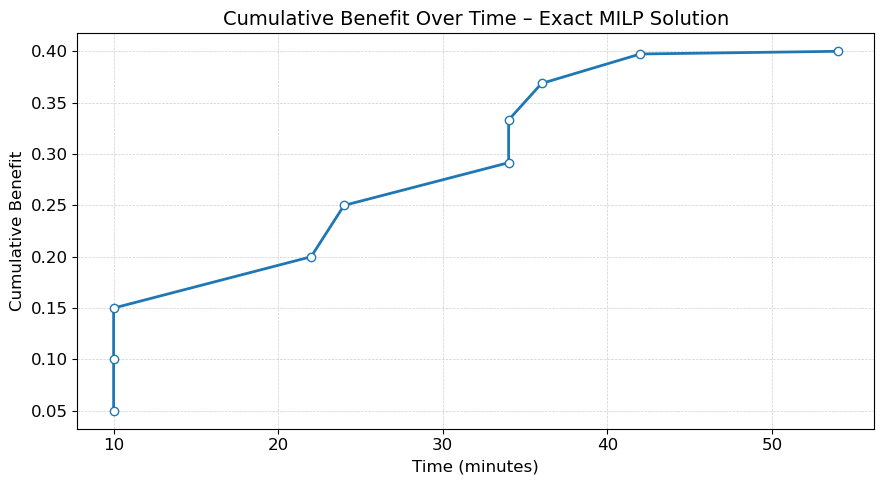

In [12]:
import matplotlib.pyplot as plt

# 1. Preparación de datos (usando las listas que ya tienes en memoria)
paired = sorted(zip(completion_times, individual_benefits), key=lambda x: x[0])
if paired:
    sorted_times, sorted_deltas = zip(*paired)

    # Beneficio acumulado
    cum, y = 0, []
    for d in sorted_deltas:
        cum += d
        y.append(cum)

    # Estilo estético (Réplica de tu estilo Greedy)
    plt.figure(figsize=(9, 5))
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.size": 12
    })

    # Curva y puntos (Mismo color y formato que tu Greedy)
    plt.plot(sorted_times, y, marker='o', markersize=6, 
             markerfacecolor='white', markeredgecolor='#1f77b4', 
             color='#1f77b4', linewidth=2)

    # Ejes y grilla elegante
    plt.xlabel("Time (minutes)")
    plt.ylabel("Cumulative Benefit")
    plt.title("Cumulative Benefit Over Time – Exact MILP Solution", fontsize=14)
    plt.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.6)

    plt.tight_layout()
    plt.show()
else:
    print("Sin datos: Asegúrate de ejecutar la celda del solver primero.")

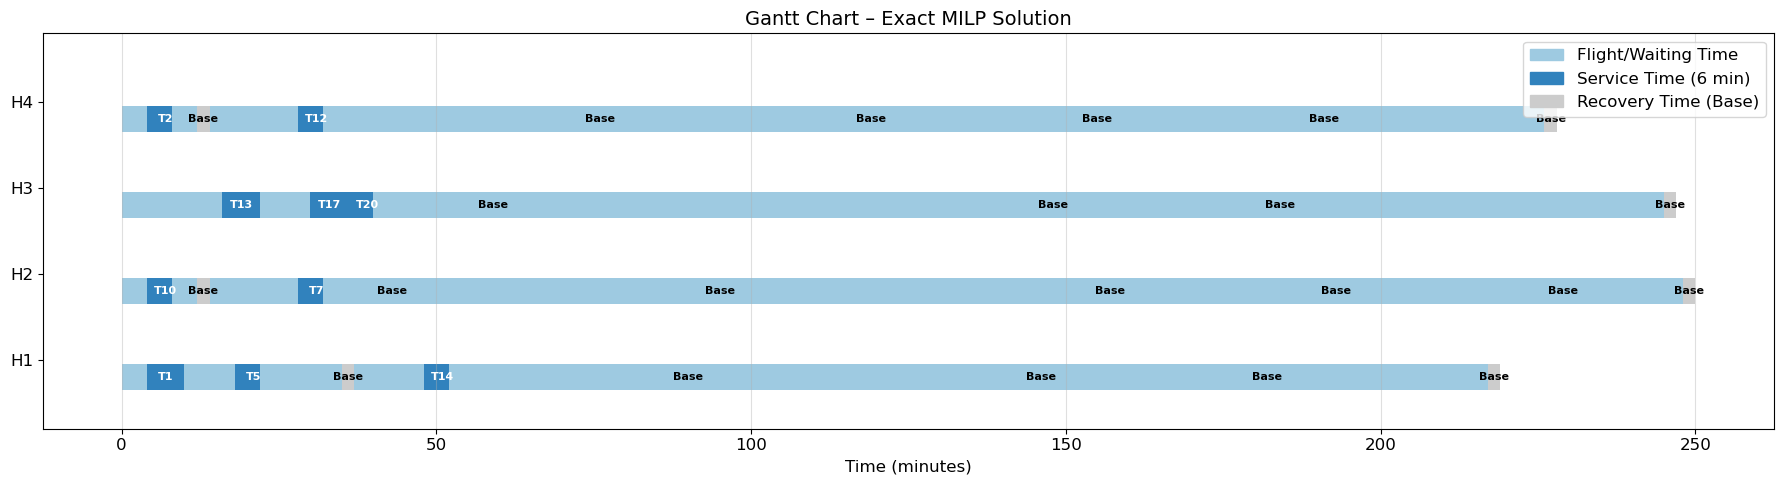

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_exact_gantt(df_capacity):
    # Preparar datos (usando el DataFrame generado en la Sección 7)
    records = []
    
    # En el MILP, calculamos el 'start' real basándonos en la duración
    for _, row in df_capacity.iterrows():
        heli = int(row["Helo ID"])
        task = row["Task ID"]
        finish = float(row["Completion Time"])
        service = float(row["Service Time"])
        flight = float(row["Flight Time"])
        
        # El inicio del bloque de viaje se calcula hacia atrás desde el fin
        start_block = finish - service - flight
        
        records.append({
            "heli": heli,
            "task": task,
            "start": start_block,
            "travel": flight,
            "service": service,
            "status": row["Status"]
        })

    # Graficar
    fig, ax = plt.subplots(figsize=(18, 5))
    colors = dict(travel="#9ecae1", service="#3182bd", idle="#cccccc")

    for rec in records:
        y = rec["heli"]
        # Bloque de Viaje/Espera
        if rec["travel"] > 0:
            ax.broken_barh([(rec["start"], rec["travel"])], (y-0.35, 0.3),
                            facecolors=colors["travel"])
        # Bloque de Servicio o Base
        ax.broken_barh([(rec["start"]+rec["travel"], rec["service"])], (y-0.35, 0.3),
                        facecolors=colors["service"] if rec["status"] == "Task Executed" else colors["idle"])

        label = f"T{rec['task']}" if rec["status"] == "Task Executed" else "Base"
        txt_color = 'white' if rec["status"] == "Task Executed" else 'black'
        ax.text(rec["start"]+rec["travel"]+rec["service"]/2, y-0.35+0.15,
                label, ha='center', va='center', color=txt_color, fontsize=8, fontweight='bold')

    ax.set_xlabel("Time (minutes)")
    ax.set_yticks(sorted(set(r["heli"] for r in records)))
    ax.set_yticklabels([f"H{i}" for i in sorted(set(r["heli"] for r in records))])
    ax.set_title("Gantt Chart – Exact MILP Solution", fontsize=14)
    ax.grid(axis='x', alpha=0.4)
    ax.set_ylim(0.2, max(r["heli"] for r in records) + 0.8)

    patches = [
        mpatches.Patch(color=colors["travel"], label="Flight/Waiting Time"),
        mpatches.Patch(color=colors["service"], label="Service Time (6 min)"),
        mpatches.Patch(color=colors["idle"], label="Recovery Time (Base)")
    ]
    ax.legend(handles=patches, loc="upper right")
    plt.tight_layout()
    plt.show()

# Ejecutar usando el DF del MILP
plot_exact_gantt(df_capacity_exact)